# scRAW notebook

This notebook focuses on the scRAW training procedure on the Baron demo dataset.

- preprocess one `AnnData` matrix;
- define the autoencoder structure;
- show how reconstruction loss and rare-cell triplet loss are combined;
- run a notebook-friendly 30-epoch demo with saved outputs;
- display a metrics table and one UMAP figure comparing ground truth and predictions.

For the full default benchmark, remove the epoch overrides in the configuration cell.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import sys
import time
import warnings

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

ROOT = Path.cwd().resolve()
if not (ROOT / "configs").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from scraw import load_config
from scraw.clustering import final_clustering, pseudo_labels
from scraw.metrics import compute_metrics
from scraw.model import encode_in_batches, parse_hidden_layers, resolve_device
from scraw.preprocessing import preprocess_adata
from scraw.trainer import (
    _apply_random_mask,
    _combined_cell_weights,
    _rare_triplet_loss,
    _reduce_mse_per_sample,
)

warnings.filterwarnings(
    "ignore",
    message="In the future, the default backend for leiden will be igraph instead of leidenalg.",
    category=FutureWarning,
)
warnings.filterwarnings(
    "ignore",
    message="y_pred contains classes not in y_true",
    category=UserWarning,
)
warnings.filterwarnings(
    "ignore",
    message="n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.",
    category=UserWarning,
)


def detect_label_key(adata, configured_key):
    if configured_key and configured_key in adata.obs.columns:
        return configured_key
    for candidate in ["Group", "label", "cell_type", "celltype", "CellType", "cell_types"]:
        if candidate in adata.obs.columns:
            return candidate
    return None


def to_dense_float32(matrix):
    values = matrix.toarray() if hasattr(matrix, "toarray") else np.asarray(matrix)
    return np.asarray(values, dtype=np.float32)


In [2]:
config = load_config(ROOT / "configs" / "default_scraw.json")
config.data.output_dir = str(ROOT / "results" / "notebook_demo")

# Notebook-friendly defaults for an interactive demo.
config.training.epochs = 30
config.training.warmup_epochs = 10
config.triplet.start_epoch = 12

print("Notebook demo override: 30 epochs / 10 warmup epochs / triplet start epoch 12. Remove these lines for the full default run.")
display(
    pd.DataFrame(
        [
            ("data_path", config.data.data_path),
            ("device", config.runtime.device),
            ("hidden_layers", str(config.model.hidden_layers)),
            ("latent_dim", config.model.latent_dim),
            ("epochs", config.training.epochs),
            ("warmup_epochs", config.training.warmup_epochs),
            ("triplet_start_epoch", config.triplet.start_epoch),
            ("batch_size", config.training.batch_size),
            ("pseudo_label_method", config.clustering.pseudo_label_method),
            ("triplet_enabled", config.triplet.enabled),
        ],
        columns=["parameter", "value"],
    )
)


Notebook demo override: 30 epochs / 10 warmup epochs / triplet start epoch 12. Remove these lines for the full default run.


,parameter,value
0,data_path,data/baron_human_pancreas.h5ad
1,device,cuda
2,hidden_layers,"[512, 256, 128]"
3,latent_dim,192
4,epochs,30
5,warmup_epochs,10
6,triplet_start_epoch,12
7,batch_size,192
8,pseudo_label_method,leiden
9,triplet_enabled,True


In [3]:
adata_raw = sc.read_h5ad(ROOT / config.data.data_path)
label_key = detect_label_key(adata_raw, config.data.label_key)

adata_proc = preprocess_adata(adata_raw, config.preprocessing)
X_proc = to_dense_float32(adata_proc.X)

true_labels = None
if label_key is not None and label_key in adata_proc.obs.columns:
    true_labels = np.asarray(adata_proc.obs[label_key].astype(str).to_numpy(), dtype=object)

print(f"Processed matrix: {X_proc.shape[0]} cells x {X_proc.shape[1]} genes")
print(f"Label column: {label_key or 'none detected'}")


Processed matrix: 8569 cells x 2000 genes
Label column: Group


## Notebook scope

This notebook is intentionally simpler than the production pipeline.

It differs from the reference implementation in `src/scraw/trainer.py` and
`src/scraw/pipeline.py` in three ways:

- it uses notebook-local helper functions (`DemoAutoencoder`, `run_demo_epoch`,
  `train_scraw_demo`) to expose the training logic step by step;
- it runs a shorter demo by default (`30` epochs, `10` warmup epochs, triplet
  start at epoch `12`) instead of the full benchmark defaults from
  `configs/default_scraw.json`;
- it focuses on the reconstruction + rare-cell triplet path and the final
  clustering outputs, rather than reproducing every production concern
  such as export plumbing or the full trainer API surface.

The authoritative implementation for final runs remains the source code in
`src/scraw/`.


## Training procedure

The next four cells define the main components of the scRAW procedure:

- the symmetric MLP autoencoder;
- the pseudo-label refresh and rare-cell weighting step;
- one epoch of training;
- the end-to-end demo training loop with a short epoch/loss progress indicator.


In [4]:
@dataclass
class DemoResult:
    model: nn.Module
    device: str
    embeddings: np.ndarray
    labels: np.ndarray
    pseudo_labels: np.ndarray
    cell_weights: np.ndarray
    loss_history: list[dict[str, float]]


class DemoAutoencoder(nn.Module):

    def __init__(self, input_dim: int, config) -> None:
        super().__init__()
        hidden_layers = parse_hidden_layers(config.hidden_layers)

        encoder_layers = []
        previous_dim = int(input_dim)
        for hidden_dim in hidden_layers:
            encoder_layers.extend(
                [
                    nn.Linear(previous_dim, hidden_dim),
                    nn.BatchNorm1d(hidden_dim),
                    nn.LeakyReLU(),
                    nn.Dropout(float(config.dropout)),
                ]
            )
            previous_dim = hidden_dim
        encoder_layers.append(nn.Linear(previous_dim, int(config.latent_dim)))

        decoder_layers = []
        previous_dim = int(config.latent_dim)
        for hidden_dim in reversed(hidden_layers):
            decoder_layers.extend(
                [
                    nn.Linear(previous_dim, hidden_dim),
                    nn.BatchNorm1d(hidden_dim),
                    nn.LeakyReLU(),
                    nn.Dropout(float(config.dropout)),
                ]
            )
            previous_dim = hidden_dim
        decoder_layers.append(nn.Linear(previous_dim, int(input_dim)))

        self.encoder = nn.Sequential(*encoder_layers)
        self.decoder = nn.Sequential(*decoder_layers)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        z = self.encoder(x)
        recon = self.decoder(z)
        return z, recon


In [5]:
def refresh_cell_weights(model, X, config, device):
    embeddings = encode_in_batches(
        model,
        X,
        device=device,
        batch_size=int(config.training.batch_size),
    )
    pseudo = pseudo_labels(
        embeddings,
        config=config.clustering,
        runtime=config.runtime,
    )
    weight_parts = _combined_cell_weights(embeddings, pseudo, config)
    return pseudo, np.asarray(weight_parts["cell_weights"], dtype=np.float32)


def should_print_progress(epoch, total_epochs):
    if total_epochs <= 10:
        return True
    return (
        epoch == 0
        or (epoch + 1) == total_epochs
        or ((epoch + 1) % 5) == 0
    )


In [6]:
def blend_weight_vectors(previous_weights, new_weights, config):
    momentum = float(np.clip(config.weighting.dynamic_weight_momentum, 0.0, 1.0))
    blended = (
        momentum * previous_weights + (1.0 - momentum) * new_weights
    ).astype(np.float32, copy=False)
    mean_weight = float(np.mean(blended))
    if np.isfinite(mean_weight) and mean_weight > 0.0:
        blended = blended / mean_weight
    return np.clip(
        blended,
        float(config.weighting.min_cell_weight),
        float(config.weighting.max_cell_weight),
    ).astype(np.float32, copy=False)


def run_demo_epoch(model, loader, optimizer, current_weights, current_pseudo, config, device, weighted_phase, epoch):
    model.train()
    total_sum = 0.0
    reconstruction_sum = 0.0
    triplet_sum = 0.0
    n_batches = 0

    for xb, idx_tensor in loader:
        xb = xb.to(device)
        idx = idx_tensor.detach().cpu().numpy()

        if float(config.training.masking_rate) > 0.0 and (
            (not weighted_phase) or bool(config.training.masking_in_weighted_phase)
        ):
            x_in, mask = _apply_random_mask(
                xb,
                rate=float(config.training.masking_rate),
                masking_value=float(config.training.masking_value),
            )
        else:
            x_in, mask = xb, None

        z, recon = model(x_in)
        loss_per_sample = _reduce_mse_per_sample(
            target=xb,
            recon=recon,
            mask=mask,
            masked_recon_weight=float(config.training.masked_recon_weight),
        )

        if weighted_phase:
            weight_tensor = torch.tensor(current_weights[idx], dtype=torch.float32, device=device)
            reconstruction_loss = torch.mean(loss_per_sample * weight_tensor)
        else:
            weight_tensor = torch.ones(xb.shape[0], dtype=torch.float32, device=device)
            reconstruction_loss = torch.mean(loss_per_sample)

        triplet_loss = torch.tensor(0.0, device=device)
        triplet_active = (
            bool(config.triplet.enabled)
            and float(config.triplet.weight) > 0.0
            and weighted_phase
            and epoch >= int(config.triplet.start_epoch)
        )
        if triplet_active:
            triplet_loss = _rare_triplet_loss(
                z,
                pseudo_labels_batch=current_pseudo[idx],
                weights_batch=weight_tensor,
                config=config,
            )
            ramp_epochs = max(
                1,
                min(20, int(config.training.epochs) - int(config.triplet.start_epoch)),
            )
            triplet_ramp = min(1.0, (epoch - int(config.triplet.start_epoch)) / ramp_epochs)
        else:
            triplet_ramp = 0.0

        total_loss = reconstruction_loss + (
            triplet_ramp * float(config.triplet.weight) * triplet_loss
        )

        optimizer.zero_grad(set_to_none=True)
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=float(config.training.gradient_clip),
        )
        optimizer.step()

        total_sum += float(total_loss.detach().cpu().item())
        reconstruction_sum += float(reconstruction_loss.detach().cpu().item())
        triplet_sum += float(triplet_loss.detach().cpu().item())
        n_batches += 1

    return {
        "total_loss": total_sum / max(1, n_batches),
        "reconstruction_loss": reconstruction_sum / max(1, n_batches),
        "triplet_loss": triplet_sum / max(1, n_batches),
    }


In [7]:
def train_scraw_demo(X, config):
    torch.manual_seed(int(config.runtime.seed))
    np.random.seed(int(config.runtime.seed))

    X = np.asarray(X, dtype=np.float32)
    device = resolve_device(config.runtime.device)
    model = DemoAutoencoder(input_dim=X.shape[1], config=config.model).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=float(config.training.learning_rate))
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(1, int(config.training.epochs)),
        eta_min=float(config.training.learning_rate) * 0.01,
    )

    loader = DataLoader(
        TensorDataset(torch.from_numpy(X).float(), torch.arange(X.shape[0], dtype=torch.long)),
        batch_size=int(config.training.batch_size),
        shuffle=True,
    )

    current_weights = np.ones(X.shape[0], dtype=np.float32)
    current_pseudo = np.zeros(X.shape[0], dtype=np.int64)
    loss_history = []
    total_epochs = int(config.training.epochs)

    for epoch in range(total_epochs):
        weighted_phase = epoch >= int(config.training.warmup_epochs)
        refresh_interval = int(config.weighting.dynamic_weight_update_interval)
        should_refresh_weights = weighted_phase and (
            epoch == int(config.training.warmup_epochs)
            or (refresh_interval > 0 and ((epoch - int(config.training.warmup_epochs)) % refresh_interval == 0))
        )

        if should_refresh_weights:
            pseudo_for_weights, new_weights = refresh_cell_weights(model, X, config, device)
            if epoch == int(config.training.warmup_epochs):
                current_weights = new_weights
            else:
                current_weights = blend_weight_vectors(current_weights, new_weights, config)
            current_pseudo = pseudo_for_weights

        epoch_stats = run_demo_epoch(
            model=model,
            loader=loader,
            optimizer=optimizer,
            current_weights=current_weights,
            current_pseudo=current_pseudo,
            config=config,
            device=device,
            weighted_phase=weighted_phase,
            epoch=epoch,
        )
        scheduler.step()

        phase = "weighted" if weighted_phase else "warmup"
        loss_history.append(
            {
                "epoch": int(epoch),
                "phase": phase,
                "total_loss": epoch_stats["total_loss"],
                "reconstruction_loss": epoch_stats["reconstruction_loss"],
                "triplet_loss": epoch_stats["triplet_loss"],
            }
        )
        if should_print_progress(epoch, total_epochs):
            print(
                f"Epoch {epoch + 1}/{total_epochs} phase={phase} total_loss={epoch_stats['total_loss']:.4f} recon_loss={epoch_stats['reconstruction_loss']:.4f} triplet_loss={epoch_stats['triplet_loss']:.4f}",
                flush=True,
            )

    final_embeddings = encode_in_batches(
        model,
        X,
        device=device,
        batch_size=int(config.training.batch_size),
    )
    final_labels = final_clustering(
        final_embeddings,
        config=config.clustering,
        runtime=config.runtime,
    )

    return DemoResult(
        model=model,
        device=str(device),
        embeddings=final_embeddings,
        labels=final_labels,
        pseudo_labels=current_pseudo,
        cell_weights=current_weights,
        loss_history=loss_history,
    )


t0 = time.time()
result = train_scraw_demo(X_proc, config)
runtime_s = time.time() - t0

metrics = compute_metrics(true_labels, result.labels, result.embeddings)
metrics_df = pd.Series(
    {key: value for key, value in metrics.items() if not isinstance(value, (dict, list))},
    name="value",
).to_frame()
loss_tail_df = pd.DataFrame(result.loss_history).tail(5)

print(f"Run completed in {runtime_s:.1f} s on {result.device}")
display(metrics_df.round(4))
display(loss_tail_df.round(4))


Epoch 1/30 phase=warmup total_loss=0.6872 recon_loss=0.6872 triplet_loss=0.0000
Epoch 5/30 phase=warmup total_loss=0.5838 recon_loss=0.5838 triplet_loss=0.0000
Epoch 10/30 phase=warmup total_loss=0.5645 recon_loss=0.5645 triplet_loss=0.0000
Epoch 15/30 phase=weighted total_loss=0.9760 recon_loss=0.9749 triplet_loss=0.0414
Epoch 20/30 phase=weighted total_loss=0.9551 recon_loss=0.9545 triplet_loss=0.0074
Epoch 25/30 phase=weighted total_loss=0.8905 recon_loss=0.8893 triplet_loss=0.0074
Epoch 30/30 phase=weighted total_loss=0.8894 recon_loss=0.8883 triplet_loss=0.0051
Run completed in 466.1 s on cuda


,value
NMI,0.8215
ARI,0.7819
ACC,0.8586
UCA,0.8586
F1_Macro,0.5842
BalancedACC,0.6140
RareACC,0.7107
KNN_Purity,0.7248
Silhouette,0.6415
n_clusters_found,10.0000


,epoch,phase,total_loss,reconstruction_loss,triplet_loss
25,25,weighted,0.8908,0.8899,0.0053
26,26,weighted,0.8881,0.8870,0.0062
27,27,weighted,0.8940,0.8930,0.0052
28,28,weighted,0.8888,0.8876,0.0056
29,29,weighted,0.8894,0.8883,0.0051


In [8]:
def project_to_2d(embeddings, seed):
    emb = np.asarray(embeddings, dtype=np.float32)
    if emb.shape[0] == 0:
        return np.zeros((0, 2), dtype=np.float32)
    if emb.shape[1] == 1:
        return np.column_stack([emb[:, 0], np.zeros(emb.shape[0], dtype=np.float32)])
    if emb.shape[1] == 2:
        return emb.astype(np.float32, copy=False)

    try:
        import umap

        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=min(15, max(2, emb.shape[0] - 1)),
            min_dist=0.3,
            random_state=int(seed),
        )
        return reducer.fit_transform(emb).astype(np.float32, copy=False)
    except Exception:
        from sklearn.decomposition import PCA

        return PCA(n_components=2, random_state=int(seed)).fit_transform(emb).astype(
            np.float32,
            copy=False,
        )


def scatter_panel(ax, coords, labels, title):
    labels = np.asarray(labels, dtype=object)
    unique_labels = sorted(np.unique(labels).tolist())
    mapping = {label: idx for idx, label in enumerate(unique_labels)}
    encoded = np.asarray([mapping[label] for label in labels], dtype=np.int64)

    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=encoded,
        cmap=plt.get_cmap("tab20", max(1, len(unique_labels))),
        s=8,
        alpha=0.85,
        linewidths=0,
        rasterized=True,
    )
    ax.set_title(f"{title} ({len(unique_labels)} labels)")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")


def plot_ground_truth_vs_predictions(embeddings, labels_true, labels_pred, seed):
    coords = project_to_2d(embeddings, seed)
    if labels_true is None:
        labels_true = np.asarray(["no_ground_truth"] * coords.shape[0], dtype=object)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
    scatter_panel(axes[0], coords, labels_true, "Ground truth")
    scatter_panel(axes[1], coords, labels_pred, "Predicted clusters")
    plt.tight_layout()
    return fig


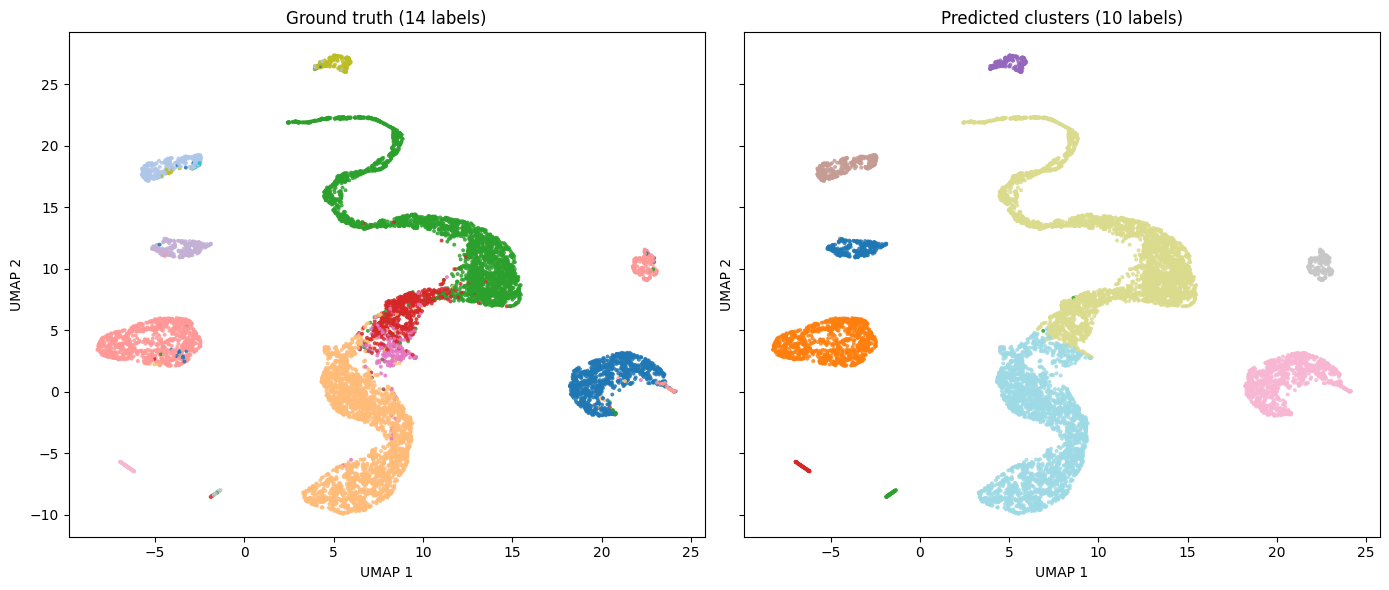

In [9]:
umap_fig = plot_ground_truth_vs_predictions(
    result.embeddings,
    true_labels,
    result.labels,
    seed=int(config.runtime.seed),
)
display(umap_fig)
plt.close(umap_fig)
